##Cost and Insurance Analysis of Patient Visit Demo Dataset Part I

In [2]:
import sys
print(sys.executable) # proves the venv is used

/Users/rajonkar/Documents/MyLearning/.venv/bin/python


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
path='/Users/rajonkar/Documents/MyLearning/Ex_Files_Python_Data_Analysis_Healthcare/Exercise Files/Demo Hospital Outpatient Data Clean_NHC.csv'
df_visit = pd.read_csv(path)

In [ ]:
# df_visit = pd.read_csv("/content/demo_hospital_outpatient_data_clean.zip")
# df_visit.head()

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration(minutes),Nursing(minutes),Laboratory(minutes),Consultation(minutes),Pharmacy(minutes)
0,2020-05-06,688923,68,Female,Diabetes,True,20006,2274.0,33.0,105.0,101.0,28.0,112.0
1,2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430.0,46.0,75.0,84.0,102.0,36.0
2,2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836.0,107.0,81.0,5.0,77.0,36.0
3,2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250.0,66.0,31.0,101.0,35.0,92.0
4,2018-04-30,454666,24,Male,Malaria,True,10006,2262.0,68.0,55.0,60.0,90.0,104.0


In [5]:
avg_cost_by_gender = df_visit.groupby('Gender')['Total_Cost'].mean()
avg_cost_by_gender

Gender
Female    2632.877112
Male      2618.993034
Name: Total_Cost, dtype: float64

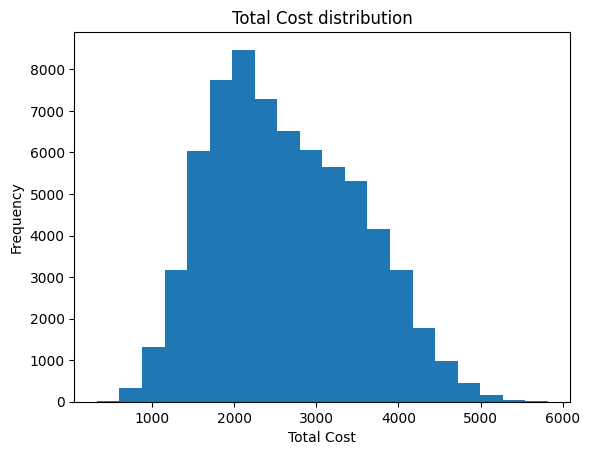

In [9]:
plt.hist(df_visit['Total_Cost'], bins=20)
plt.title('Total Cost distribution')
plt.xlabel('Total Cost')
plt.ylabel("Frequency")
plt.show()

In [10]:
avg_cost_by_insurance = df_visit[df_visit['Has_Insurance'] == True]['Total_Cost'].mean()
avg_cost_by_insurance

np.float64(1876.0660470202297)

In [11]:
avg_cost_without_insurance = df_visit[df_visit['Has_Insurance'] == False]['Total_Cost'].mean()
avg_cost_without_insurance

np.float64(3125.477213683929)

In [28]:
df_visit['Visit_Date'] = pd.to_datetime(df_visit['Visit_Date'])
df_visit.set_index("Visit_Date", inplace=True)

In [30]:
# df_visit['Visit_Date'] = pd.to_datetime(df_visit['Visit_Date'])
# df_visit.set_index("Visit_Date", inplace=True)
annual_total_cost = df_visit['Total_Cost'].resample("YE").sum()

In [31]:
annual_total_cost

Visit_Date
2018-12-31    36072456.0
2019-12-31    36783096.0
2020-12-31    36227058.0
2021-12-31    35737294.0
2022-12-31    35378998.0
Freq: YE-DEC, Name: Total_Cost, dtype: float64

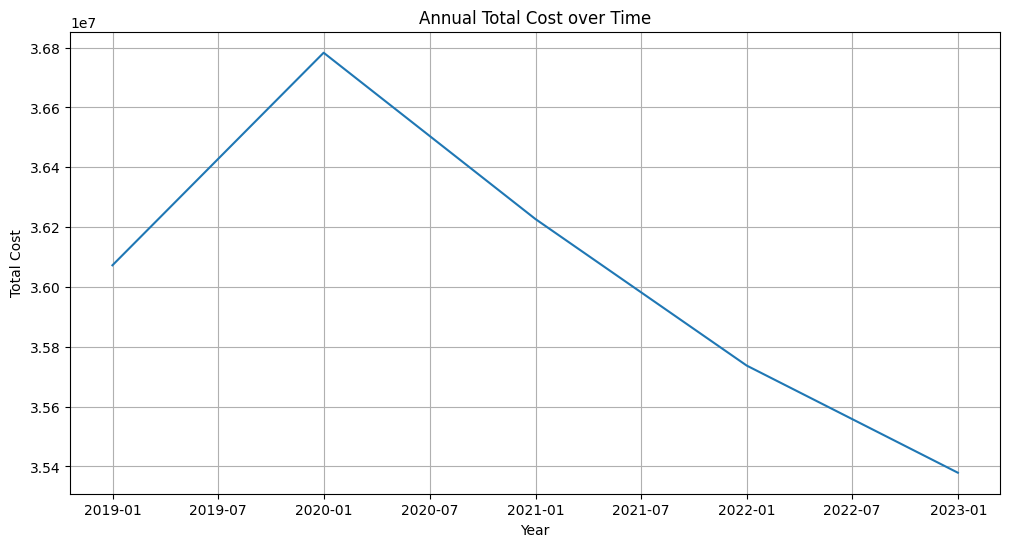

In [32]:
plt.figure(figsize=(12,6))
plt.plot(annual_total_cost.index, annual_total_cost.values)
plt.title("Annual Total Cost over Time")
plt.xlabel("Year")
plt.ylabel("Total Cost")
plt.grid(True)
plt.show()

##Cost and Insurance Analysis of Patient Visit Demo Dataset Part II

In [33]:
df_visit = df_visit.reset_index()

In [34]:
df_visit.set_index('Visit_Date', inplace=True)
df_visit.head()

,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration(minutes),Nursing(minutes),Laboratory(minutes),Consultation(minutes),Pharmacy(minutes)
Visit_Date,,,,,,,,,,,,
2020-05-06,688923,68,Female,Diabetes,True,20006,2274.0,33.0,105.0,101.0,28.0,112.0
2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430.0,46.0,75.0,84.0,102.0,36.0
2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836.0,107.0,81.0,5.0,77.0,36.0
2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250.0,66.0,31.0,101.0,35.0,92.0
2018-04-30,454666,24,Male,Malaria,True,10006,2262.0,68.0,55.0,60.0,90.0,104.0


In [ ]:
has_insurance_true_data = df_visit[df_visit['Has_Insurance'] == True]['Total_Cost'].resample('YE').sum()
has_insurance_false_data = df_visit[df_visit['Has_Insurance'] == False]['Total_Cost'].resample('YE').sum()

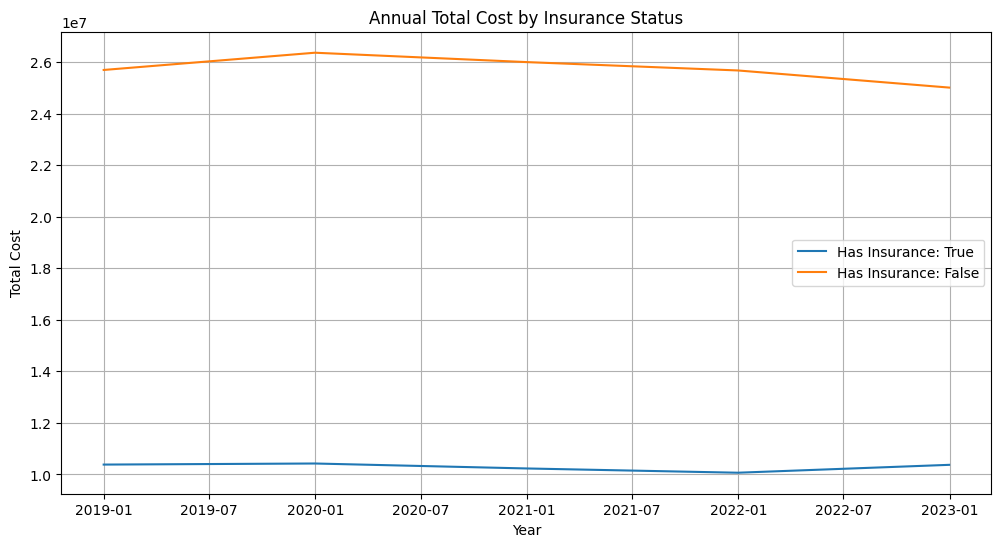

In [16]:
plt.figure(figsize=(12,6))
plt.plot(has_insurance_true_data.index, has_insurance_true_data.values,label='Has Insurance: True')
plt.plot(has_insurance_false_data.index, has_insurance_false_data.values,label='Has Insurance: False')
plt.title('Annual Total Cost by Insurance Status')
plt.xlabel('Year')
plt.ylabel('Total Cost')
plt.grid(True)
plt.legend()
plt.show()